In [60]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score

In [61]:
df = pd.read_csv("../dataset/protein_balanced.csv")

df.head()

,sequence,label
0,MSDQFNSREARRKANSKSSPSPKKGKKRKKGGLFKKTLFTLLILFV...,binding
1,MSEPLLHLTGISRSFTAGDREFLALKHIDLSIQAGEMVAITGASGS...,binding
2,MKVNPNNIELIISAVKEEQYPETELSEVALSGRSNVGKSTFINSMI...,binding
3,MARYDLVDRLNTTFRQMEQELAAFAAHLEQHKLLVARVFSLPEVKK...,binding
4,MFWGIEISKVPVKFTPAFDLHITTACLSAVAKDTGRNVLQVKYDGK...,binding


In [62]:
df_cnn = df.groupby("label").sample(n=5000, random_state=42)

df_cnn["label"].value_counts()

label
binding      5000
enzyme       5000
transport    5000
Name: count, dtype: int64

In [63]:
amino_acids = "ACDEFGHIKLMNPQRSTVWY"
aa_to_int = {aa: i+1 for i, aa in enumerate(amino_acids)}

MAX_LEN = 300

def encode_sequence(seq):
    seq = seq.upper()
    encoded = [aa_to_int.get(aa, 0) for aa in seq[:MAX_LEN]]
    
    if len(encoded) < MAX_LEN:
        encoded += [0] * (MAX_LEN - len(encoded))
    
    return encoded

In [64]:
X = np.array([encode_sequence(seq) for seq in df_cnn["sequence"]])

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_cnn["label"])

print(X.shape)
print(y.shape)
print(label_encoder.classes_)

(15000, 300)
(15000,)
['binding' 'enzyme' 'transport']


In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [66]:
class ProteinDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [67]:
train_dataset = ProteinDataset(X_train, y_train)
test_dataset = ProteinDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [68]:
class ImprovedProteinCNN(nn.Module):
    def __init__(self, vocab_size=21, embed_dim=128, num_classes=3):
        super(ImprovedProteinCNN, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.conv1 = nn.Conv1d(embed_dim, 128, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(128)

        self.conv2 = nn.Conv1d(128, 256, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(256)

        self.conv3 = nn.Conv1d(256, 256, kernel_size=7, padding=3)
        self.bn3 = nn.BatchNorm1d(256)

        self.pool = nn.AdaptiveMaxPool1d(1)

        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)

        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = torch.relu(self.bn3(self.conv3(x)))

        x = self.pool(x).squeeze(-1)

        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [69]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_cnn = ImprovedProteinCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.0005)

EPOCHS = 15

for epoch in range(EPOCHS):
    model_cnn.train()
    total_loss = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model_cnn(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {total_loss/len(train_loader):.4f}")

Using device: cpu
Epoch [1/15], Loss: 0.7148
Epoch [2/15], Loss: 0.4337
Epoch [3/15], Loss: 0.3011
Epoch [4/15], Loss: 0.2049
Epoch [5/15], Loss: 0.1341
Epoch [6/15], Loss: 0.0958
Epoch [7/15], Loss: 0.0486
Epoch [8/15], Loss: 0.0254
Epoch [9/15], Loss: 0.0143
Epoch [10/15], Loss: 0.0112
Epoch [11/15], Loss: 0.0100
Epoch [12/15], Loss: 0.0186
Epoch [13/15], Loss: 0.0745
Epoch [14/15], Loss: 0.0508
Epoch [15/15], Loss: 0.0246


In [78]:
model_cnn.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        outputs = model_cnn(batch_X)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(batch_y.numpy())

accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Improved CNN Accuracy:", accuracy)
print("Improved CNN Weighted F1:", f1)

print(classification_report(
    all_labels,
    all_preds,
    target_names=label_encoder.classes_
))

Improved CNN Accuracy: 0.9083333333333333
Improved CNN Weighted F1: 0.9081643405538553
              precision    recall  f1-score   support

     binding       0.91      0.90      0.91      1000
      enzyme       0.91      0.88      0.90      1000
   transport       0.90      0.94      0.92      1000

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.91      0.91      3000



In [79]:
torch.save(model_cnn.state_dict(), "../models/cnn_model.pth")

In [75]:
import pandas as pd

comparison = {
    "Model": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + Random Forest",
        "TF-IDF + SVM",

        "1D CNN (5 Epochs, 15000)",
        "1D CNN (5 Epochs, 21000)",
        "1D CNN (15 Epochs, 15000)",

        "ESM + SVC (1500)",
        "ESM + SVC (9000)",
        "ESM + SVC (15000)"
    ],

    "Accuracy": [
        0.90,
        0.88,
        0.91,

        0.83,
        0.86,
        0.91,

        0.88,
        0.93,
        0.94
    ],

    "Category": [
        "Classical ML",
        "Classical ML",
        "Classical ML",

        "Deep Learning",
        "Deep Learning",
        "Deep Learning",

        "Transformer Embedding",
        "Transformer Embedding",
        "Transformer Embedding"
    ]
}

df_compare = pd.DataFrame(comparison)

# Sort by accuracy
df_compare = df_compare.sort_values(by="Accuracy", ascending=True)

df_compare

,Model,Accuracy,Category
3,"1D CNN (5 Epochs, 15000)",0.83,Deep Learning
4,"1D CNN (5 Epochs, 21000)",0.86,Deep Learning
6,ESM + SVC (1500),0.88,Transformer Embedding
1,TF-IDF + Random Forest,0.88,Classical ML
0,TF-IDF + Logistic Regression,0.90,Classical ML
2,TF-IDF + SVM,0.91,Classical ML
5,"1D CNN (15 Epochs, 15000)",0.91,Deep Learning
7,ESM + SVC (9000),0.93,Transformer Embedding
8,ESM + SVC (15000),0.94,Transformer Embedding


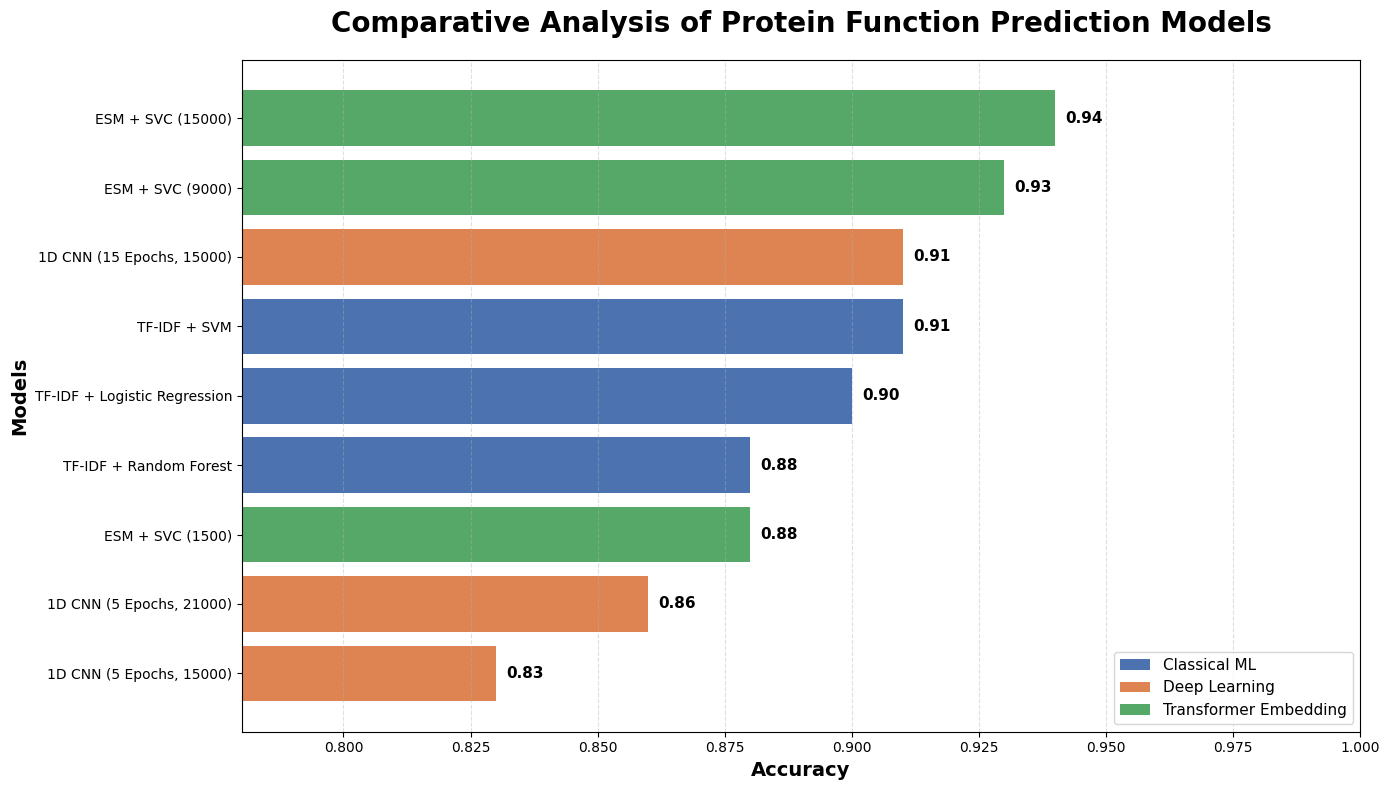

In [76]:
import matplotlib.pyplot as plt
import numpy as np

# Colors based on category
colors = []

for cat in df_compare["Category"]:
    if cat == "Classical ML":
        colors.append("#4C72B0")   # blue
    elif cat == "Deep Learning":
        colors.append("#DD8452")   # orange
    else:
        colors.append("#55A868")   # green

plt.figure(figsize=(14,8))

bars = plt.barh(
    df_compare["Model"],
    df_compare["Accuracy"],
    color=colors
)

# Accuracy labels
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# Title and labels
plt.title(
    "Comparative Analysis of Protein Function Prediction Models",
    fontsize=20,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    "Accuracy",
    fontsize=14,
    fontweight='bold'
)

plt.ylabel(
    "Models",
    fontsize=14,
    fontweight='bold'
)

# Grid
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Accuracy range
plt.xlim(0.78, 1.00)

# Legend
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#4C72B0", label='Classical ML'),
    Patch(facecolor="#DD8452", label='Deep Learning'),
    Patch(facecolor="#55A868", label='Transformer Embedding')
]

plt.legend(
    handles=legend_elements,
    loc='lower right',
    fontsize=11
)

plt.tight_layout()

plt.show()

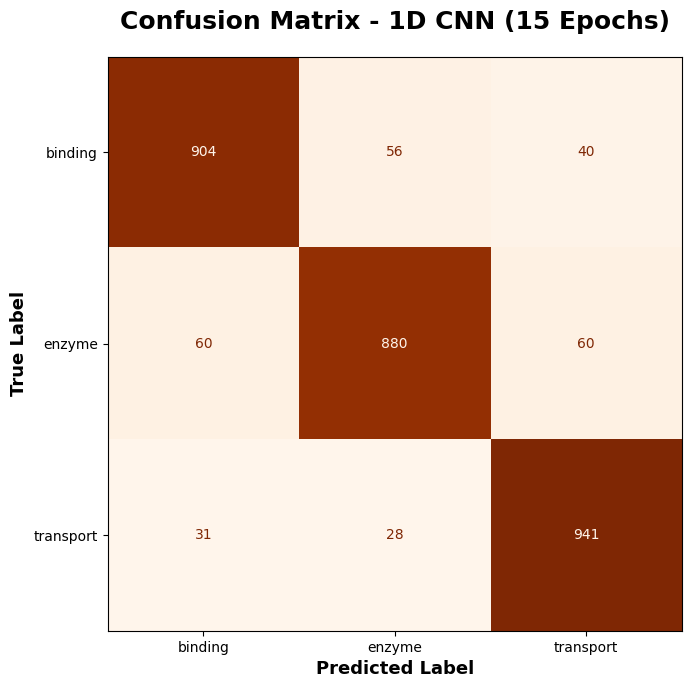

In [77]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm_cnn = confusion_matrix(all_labels, all_preds)

# Plot
fig, ax = plt.subplots(figsize=(7,7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cnn,
    display_labels=label_encoder.classes_
)

disp.plot(
    cmap="Oranges",
    values_format='d',
    ax=ax,
    colorbar=False
)

# Title
plt.title(
    "Confusion Matrix - 1D CNN (15 Epochs)",
    fontsize=18,
    fontweight='bold',
    pad=20
)

# Axis labels
plt.xlabel(
    "Predicted Label",
    fontsize=13,
    fontweight='bold'
)

plt.ylabel(
    "True Label",
    fontsize=13,
    fontweight='bold'
)

# Tight layout
plt.tight_layout()

plt.show()